# Assignemt 01 - Sentiment Analysis

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

### Sentiment Analysis Using TF-IDF Vectors

**Objective:**  
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

### Dataset Description for Sentiment Analysis Project

**Content:**  
The dataset is stored in a **CSV file** and includes six fields:

1. **Polarity (Column 0):**  
   - Sentiment label for the tweet:  
     - `0`: Negative sentiment  
     - `2`: Neutral sentiment  
     - `4`: Positive sentiment

2. **Tweet ID (Column 1):**  
   - A unique identifier for each tweet.

3. **Date (Column 2):**  
   - The timestamp of when the tweet was posted, in the format:  
     `Day Month Date HH:MM:SS UTC Year`  
     *(e.g., Sat May 16 23:58:44 UTC 2009)*

4. **Query (Column 3):**  
   - The search query used to retrieve the tweet.  
     If no query was used, the value is `NO_QUERY`.

5. **User (Column 4):**  
   - The username of the account that posted the tweet  
     *(e.g., robotickilldozr)*

6. **Text (Column 5):**  
   - The content of the tweet, consisting of raw text after emoticons have been removed  
     *(e.g., Lyx is cool)*

Dataset Source on Kaggle
  </p>
</details>

## To Do List

- [ ] Clean the better the text before doing the training. remove stop words, lemmatize etc...
- [ ] Keep the ANN simple.

## Imports

In [1]:
# import kagglehub
import pandas as pd
import html
import re

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## Read + EDA

In [2]:
train_df = pd.read_csv("../Data/train.csv", encoding="Windows-1252")
test_df = pd.read_csv("../Data/test.csv", encoding="Windows-1252")

In [3]:
train_df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [4]:
test_df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


focus only on necessary info

In [5]:
train_df = train_df[["text", "sentiment"]]
test_df = test_df[["text", "sentiment"]]

print(f"train has {len(train_df)} rows, and test has {len(test_df)} rows.")

train has 27481 rows, and test has 4815 rows.


check for Nans

In [6]:
print("train Nans")
print(train_df.isnull().sum())
print("test Nans")
print(test_df.isnull().sum())

train Nans
text         1
sentiment    0
dtype: int64
test Nans
text         1281
sentiment    1281
dtype: int64


In [7]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
print(f"{before - len(train_df)} NaN rows dropped.")
before = len(test_df)
test_df.dropna(how="any", inplace=True)
print(f"{before - len(test_df)} NaN rows dropped.")

1 NaN rows dropped.
1281 NaN rows dropped.


do basic text cleaning

In [8]:
def basic_text_clean(text):
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = text.strip()
    return text

In [9]:
train_df["text"] = train_df["text"].apply(basic_text_clean)
test_df["text"] = test_df["text"].apply(basic_text_clean)

check for duplicates

In [10]:
has_duplicates = train_df.duplicated().any()
print("train_df has duplicates:", has_duplicates)
has_duplicates = test_df.duplicated().any()
print("test_df has duplicates:", has_duplicates)

train_df has duplicates: True
test_df has duplicates: True


clean duplicates after clean text ... leads to more rows dropped

In [11]:
before = len(train_df)
train_df.drop_duplicates(inplace=True)
print(f"{before - len(train_df)} rows are dropped")
before = len(test_df)
test_df.drop_duplicates(inplace=True)
print(f"{before - len(test_df)} rows are dropped")

68 rows are dropped
5 rows are dropped


In [12]:
print(f"train has {len(train_df)} rows, and test has {len(test_df)} rows.")

train has 27412 rows, and test has 3529 rows.


polarity here is a text we will change it to 0 2 4

In [13]:
sentiment_mapping = {'negative': 0, 'neutral': 2, 'positive': 4}

In [14]:
train_df["polarity"] = train_df["sentiment"].map(sentiment_mapping)
test_df["polarity"] = test_df["sentiment"].map(sentiment_mapping)


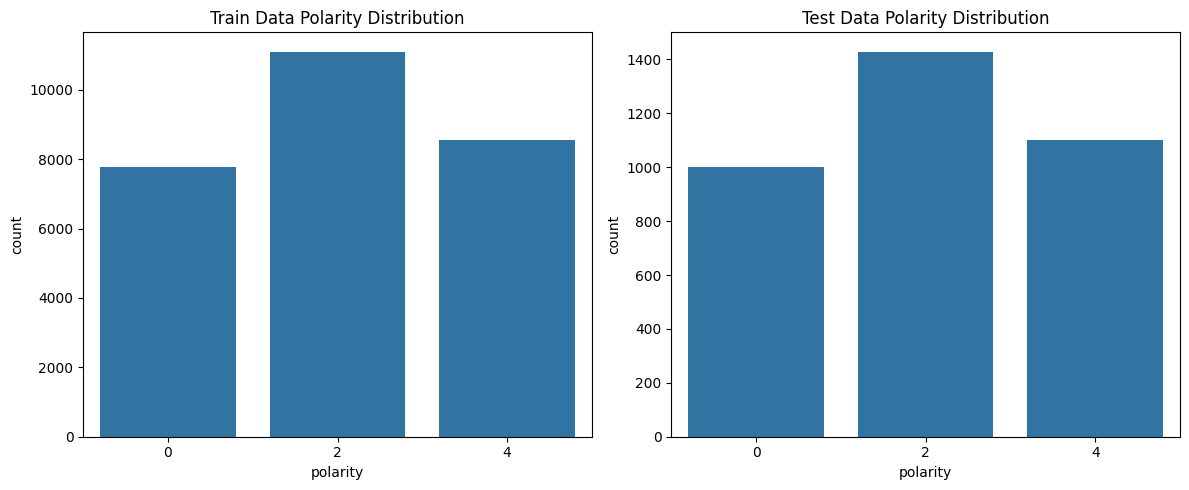

In [15]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train data polarity distribution
sns.countplot(data=train_df, x="polarity", ax=axes[0])
axes[0].set_title("Train Data Polarity Distribution")

# Test data polarity distribution
sns.countplot(data=test_df, x="polarity", ax=axes[1])
axes[1].set_title("Test Data Polarity Distribution")

plt.tight_layout()

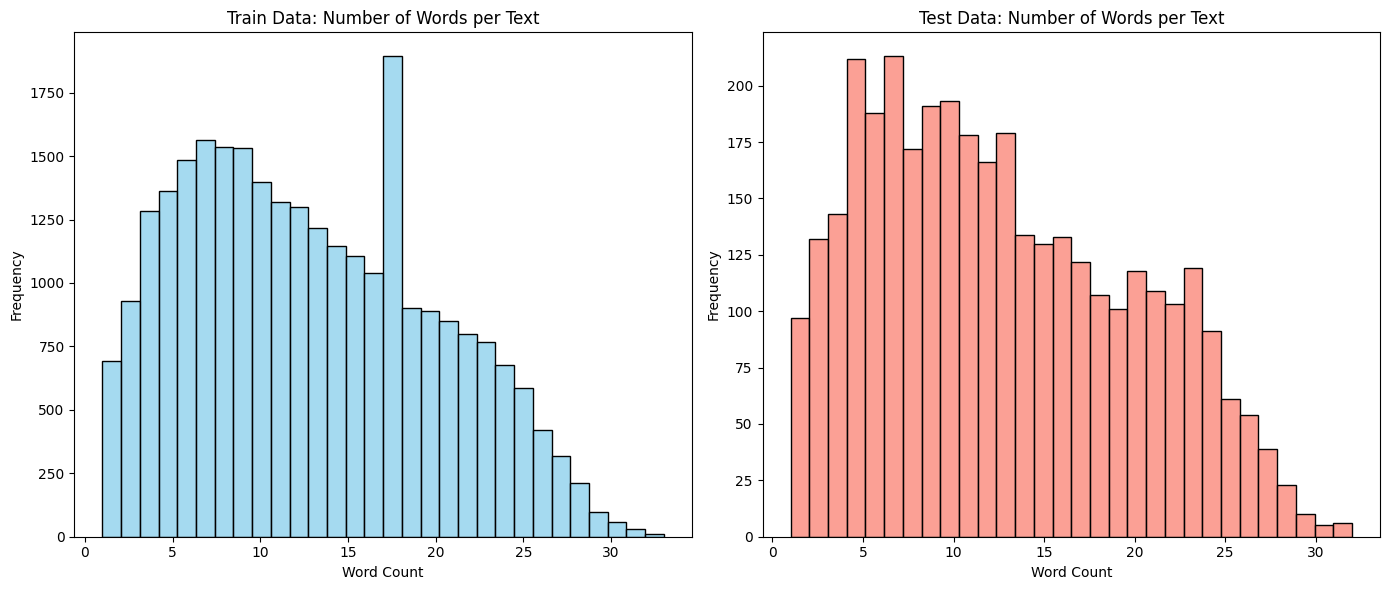

In [16]:
# Calculate word counts
train_word_counts = train_df['text'].astype(str).apply(lambda x: len(x.split()))
test_word_counts = test_df['text'].astype(str).apply(lambda x: len(x.split()))

# Create side-by-side histograms with separate y-axis scales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(train_word_counts, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Train Data: Number of Words per Text')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

sns.histplot(test_word_counts, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Test Data: Number of Words per Text')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

## TF-IDF

In [151]:
import string 

def text_preprocess(text):
    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove hashtags (keeping the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [152]:
train_df["text"] = train_df["text"].apply(text_preprocess)
test_df["text"] = test_df["text"].apply(text_preprocess)

In [175]:
tfidf_ngram_vectorizer = TfidfVectorizer(min_df=0.001, ngram_range=(1, 2), max_features=2048)
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(train_df["text"])
tfidf_ngram_vectorizer_test = tfidf_ngram_vectorizer.transform(test_df["text"])
tfidf_ngram_vectorizer.get_feature_names_out()[150:160]

array(['behind', 'being', 'believe', 'best', 'best friend', 'bet',
       'better', 'better soon', 'better than', 'between'], dtype=object)

In [176]:
train_vectors = tfidf_ngram_vectorizer_train.toarray()
print(train_vectors.shape)
test_vectors = tfidf_ngram_vectorizer_test.toarray()
print(test_vectors.shape)

(27412, 1890)
(3529, 1890)


In [177]:
# converting the features_train and features_validation 
train_vectors = torch.tensor(train_vectors, dtype=torch.float32)
test_vectors = torch.tensor(test_vectors, dtype=torch.float32)

## Model + Training + Eval

In [178]:
train_vectors.shape

torch.Size([27412, 1890])

In [179]:
# convert target variables into pytorch tensors
label_map = {0: 0, 2: 1, 4: 2}

y_train = torch.tensor(train_df["polarity"].map(label_map).to_numpy())
y_test = torch.tensor(test_df["polarity"].map(label_map).to_numpy())

In [180]:
y_train.shape
y_test.shape

torch.Size([3529])

In [181]:
# initialise TensorDataset  object
train_dataset = TensorDataset(train_vectors, y_train)
val_dataset = TensorDataset(test_vectors, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [182]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size=8, output_size=3, dropout_rate=0.43):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        # No activation here; use CrossEntropyLoss during training

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits

In [183]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [184]:
num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/30, Loss: 1.0918, Val Loss: 1.0514
Epoch 2/30, Loss: 1.0186, Val Loss: 0.9923
Epoch 3/30, Loss: 0.9595, Val Loss: 0.9376
Epoch 4/30, Loss: 0.9131, Val Loss: 0.9101
Epoch 5/30, Loss: 0.8787, Val Loss: 0.8719
Epoch 6/30, Loss: 0.8505, Val Loss: 0.8558
Epoch 7/30, Loss: 0.8298, Val Loss: 0.8419
Epoch 8/30, Loss: 0.8085, Val Loss: 0.8270
Epoch 9/30, Loss: 0.7955, Val Loss: 0.8138
Epoch 10/30, Loss: 0.7835, Val Loss: 0.8174
Epoch 11/30, Loss: 0.7725, Val Loss: 0.8028
Epoch 12/30, Loss: 0.7646, Val Loss: 0.8073
Epoch 13/30, Loss: 0.7590, Val Loss: 0.7955
Epoch 14/30, Loss: 0.7479, Val Loss: 0.7894
Epoch 15/30, Loss: 0.7435, Val Loss: 0.7859
Epoch 16/30, Loss: 0.7418, Val Loss: 0.7946
Epoch 17/30, Loss: 0.7349, Val Loss: 0.7813
Epoch 18/30, Loss: 0.7363, Val Loss: 0.7868
Epoch 19/30, Loss: 0.7281, Val Loss: 0.7759
Epoch 20/30, Loss: 0.7252, Val Loss: 0.7867
Epoch 21/30, Loss: 0.7206, Val Loss: 0.7843
Epoch 22/30, Loss: 0.7177, Val Loss: 0.7978
Epoch 23/30, Loss: 0.7155, Val Loss: 0.79

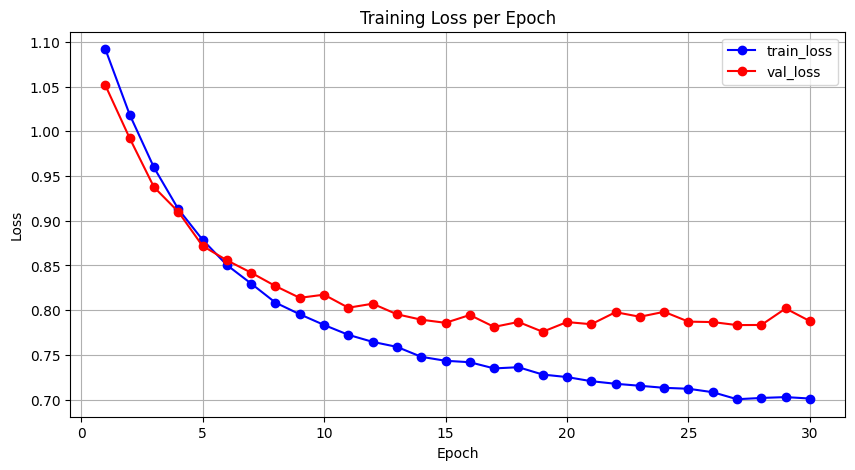

In [185]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [186]:
def calculate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)  # shape: [batch_size, num_classes]
            _, predicted = torch.max(outputs, 1)  # get index of max logit
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {val_accuracy:.2f}%')

Training Accuracy: 75.67%
Validation Accuracy: 69.85%


In [165]:
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)  # First hidden layer with 4 neurons
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.61)

        self.fc2 = nn.Linear(128, 16)  # Second hidden layer with 3 neurons
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.1)

        self.fc3 = nn.Linear(16, 3)  # Output layer with 3 neurons (for 3 sentiment classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)  # raw logits for CrossEntropyLoss
        return x


In [166]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [167]:
num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/30, Loss: 1.0407, Val Loss: 0.9037
Epoch 2/30, Loss: 0.8050, Val Loss: 0.7557
Epoch 3/30, Loss: 0.7222, Val Loss: 0.7310
Epoch 4/30, Loss: 0.6922, Val Loss: 0.7262
Epoch 5/30, Loss: 0.6709, Val Loss: 0.7207
Epoch 6/30, Loss: 0.6525, Val Loss: 0.7187
Epoch 7/30, Loss: 0.6423, Val Loss: 0.7250
Epoch 8/30, Loss: 0.6232, Val Loss: 0.7259
Epoch 9/30, Loss: 0.6126, Val Loss: 0.7320
Epoch 10/30, Loss: 0.5956, Val Loss: 0.7359
Epoch 11/30, Loss: 0.5838, Val Loss: 0.7431
Epoch 12/30, Loss: 0.5680, Val Loss: 0.7535
Epoch 13/30, Loss: 0.5495, Val Loss: 0.7601
Epoch 14/30, Loss: 0.5377, Val Loss: 0.7688
Epoch 15/30, Loss: 0.5210, Val Loss: 0.7785
Epoch 16/30, Loss: 0.5016, Val Loss: 0.7865
Epoch 17/30, Loss: 0.4890, Val Loss: 0.7990
Epoch 18/30, Loss: 0.4725, Val Loss: 0.8132
Epoch 19/30, Loss: 0.4561, Val Loss: 0.8386
Epoch 20/30, Loss: 0.4390, Val Loss: 0.8590
Epoch 21/30, Loss: 0.4302, Val Loss: 0.8728
Epoch 22/30, Loss: 0.4109, Val Loss: 0.8731
Epoch 23/30, Loss: 0.3954, Val Loss: 0.90

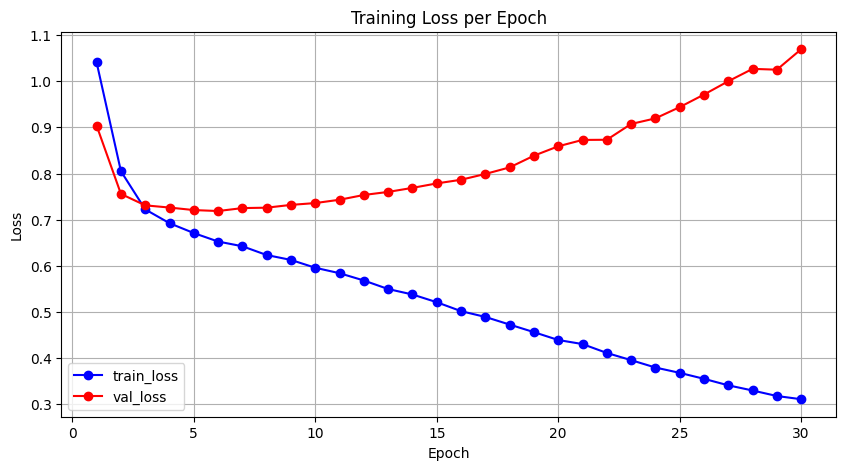

In [168]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()